# Customer Data Analysis for Business Insights

This project analyzes customer transaction data for a retail company using Python and Pandas.

Objectives:
- Clean and validate customer data
- Perform RFM analysis
- Segment customers based on purchasing behavior
- Visualize key patterns
- Generate business insights for marketing strategy

## Dataset Description

Customer_Master_Data
- CustomerID
- Name
- Email
- Gender
- Age
- City
- MaritalStatus
- NumChildren
- JoinDate

Customer_Transactions
- CustomerID
- TransactionDate
- TransactionAmount

In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# loding the datasets

# cusomter 
df_customers = pd.read_csv("Customer_Master_Data.csv")

# transaction data

df_transactions = pd.read_csv("Customer_Transactions.csv")

# print

print("Customers dataset shape: ",df_customers.shape)
print("Transactions dataset shape: ",df_transactions.shape)

# first few rows preview
print("Customer data preview")
print(df_customers.head())

print("Transaction data preview")
print(df_transactions.head())

Customers dataset shape:  (1000, 9)
Transactions dataset shape:  (23050, 3)
Customer data preview
  CustomerID            Name                    Email  Gender  Age     City  \
0  CUST10000  Onkar Bhargava          pkeer@yahoo.com    Male   54    Delhi   
1  CUST10001     Divit Kohli        mkalita@sarin.com  Female   48  Kolkata   
2  CUST10002      Kiara Behl     apteanay@hotmail.com    Male   75  Kolkata   
3  CUST10003  Vaibhav Sankar  bseshadri@choudhry.info    Male   62     Pune   
4  CUST10004    Shray D’Alia   bdhillon@toor-mall.com    Male   55    Delhi   

  MaritalStatus  NumChildren    JoinDate  
0      Divorced            0  2021-02-22  
1       Married            0  2023-12-06  
2       Widowed            2  2023-08-23  
3      Divorced            2  2022-11-17  
4      Divorced            0  2022-12-04  
Transaction data preview
  CustomerID TransactionDate  TransactionAmount
0  CUST10771         7/31/23            2383.07
1  CUST10100         3/10/24             497.54


In [3]:
# check data types

print("Customer dataset")
print(df_customers.info())

print("\nTransaction dataset")
print(df_transactions.info())

Customer dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB
None

Transaction dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  2305

In [4]:
# convert date colums [object] to date time

df_customers["JoinDate"] = pd.to_datetime(df_customers["JoinDate"])

df_transactions["TransactionDate"] = pd.to_datetime(df_transactions["TransactionDate"])

# check

print(df_customers.dtypes)
print()
print(df_transactions.dtypes)

C:\Users\shubham\AppData\Local\Temp\ipykernel_6628\3278747846.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_transactions["TransactionDate"] = pd.to_datetime(df_transactions["TransactionDate"])


CustomerID               object
Name                     object
Email                    object
Gender                   object
Age                       int64
City                     object
MaritalStatus            object
NumChildren               int64
JoinDate         datetime64[ns]
dtype: object

CustomerID                   object
TransactionDate      datetime64[ns]
TransactionAmount           float64
dtype: object


In [5]:
# check if customer id is unique in customer master data sheet

unique_customers = df_customers["CustomerID"].nunique()
total_rows = len(df_customers)

print("Total rows: ", total_rows)
print("Unique IDs: ",unique_customers)


Total rows:  1000
Unique IDs:  1000


In [6]:
# create referenence date for recency calculation

latest_date =  df_transactions["TransactionDate"].max()

reference_date = latest_date + pd.Timedelta(days=1)

print("latest tran. date: ", latest_date)
print("Reference date: ", reference_date)

latest tran. date:  2025-07-29 00:00:00
Reference date:  2025-07-30 00:00:00


## Calculate RFM Metrics

In [7]:
# Now we create the RFM table.

# For each customer:

# Recency = days since last purchase
# Frequency = number of purchases
# Monetary = total money spent

df_rfm = df_transactions.groupby("CustomerID").agg({
    "TransactionDate": "max",
    "CustomerID":"count",
    "TransactionAmount":"sum"
})

# rename colums

df_rfm.columns = ["LastPurchaseDate","Frequency","Monetary"]

# reset index so CustomerID beacomes col agaib

df_rfm = df_rfm.reset_index()

# cal. recency

df_rfm["Recency"] = (reference_date - df_rfm["LastPurchaseDate"]).dt.days

# rearrange cols

df_rfm = df_rfm[["CustomerID","Recency","Frequency","Monetary"]]

# preview

print(df_rfm.head(10))
print("\nShape of RFM: ",df_rfm.shape)

  CustomerID  Recency  Frequency  Monetary
0  CUST10000       13         23  21265.49
1  CUST10001       35         30  28654.31
2  CUST10002       18         24  23884.03
3  CUST10003       81         25  24206.03
4  CUST10004        8         19  25565.30
5  CUST10005       24         29  29459.82
6  CUST10006       11         28  27922.36
7  CUST10007       86         15  14957.06
8  CUST10008        3         19  19479.25
9  CUST10009        7         25  22832.83

Shape of RFM:  (1000, 4)


## Create RFM Scores (1–5)

In [8]:
# Logic from project instructions:

# Metric	  Rule
# Recency	  Lower days = higher score
# Frequency	  Higher purchases = higher score
# Monetary	  Higher spending = higher score

In [9]:
# recency
df_rfm["R_Score"] = pd.qcut(df_rfm["Recency"],5,labels=[5,4,3,2,1])

# frequency

df_rfm["F_Score"] = pd.qcut(df_rfm["Frequency"],5,labels=[1,2,3,4,5])

#monetary

df_rfm["M_Score"] = pd.qcut(df_rfm["Monetary"],5,labels=[1,2,3,4,5])

# preview

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST10000,13,23,21265.49,4,3,2
1,CUST10001,35,30,28654.31,3,5,5
2,CUST10002,18,24,23884.03,4,3,3
3,CUST10003,81,25,24206.03,1,4,3
4,CUST10004,8,19,25565.30,5,1,4


In [10]:
# create combined score

df_rfm["RFM_Score"]= (
    df_rfm["R_Score"].astype(str) + df_rfm["F_Score"].astype(str) + 
    df_rfm["M_Score"].astype(str)
)
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,CUST10000,13,23,21265.49,4,3,2,432
1,CUST10001,35,30,28654.31,3,5,5,355
2,CUST10002,18,24,23884.03,4,3,3,433
3,CUST10003,81,25,24206.03,1,4,3,143
4,CUST10004,8,19,25565.30,5,1,4,514


## Create Customer Segments

In [11]:
# Segment	          Rule
# Champions	          R ≥ 4 AND F ≥ 4 AND M ≥ 4
# Loyal Customers	  F ≥ 4 AND R ≥ 3
# Potential Loyalists	R ≥ 4 AND F ≥ 2
# Big Spenders	      M ≥ 4 AND F ≥ 2
# At Risk	          R ≤ 2 AND F ≥ 3
# Lost	              R = 1 AND F ≤ 2
# Others	          Remaining customers

In [12]:
# create customer segments

def assign_segment(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f>=4 and m>=4:
        return "Champions"
    elif f >=4 and r >= 3:
        return "Loyal Customers"
    elif r>=4 and f >=2:
        return "Potential Loyalists"
    elif m >=4 and f >= 2:
        return "Big Spenders"
    elif r <=2 and f >=3:
        return "At risk"
    elif r ==1 and f <= 2:
        return "Lost"
    else:
        return "Others"


df_rfm["Segment"] = df_rfm.apply(assign_segment,axis=1)

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST10000,13,23,21265.49,4,3,2,432,Potential Loyalists
1,CUST10001,35,30,28654.31,3,5,5,355,Loyal Customers
2,CUST10002,18,24,23884.03,4,3,3,433,Potential Loyalists
3,CUST10003,81,25,24206.03,1,4,3,143,At risk
4,CUST10004,8,19,25565.30,5,1,4,514,Others


In [13]:
# Count customers in each segment
segment_counts = df_rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'CustomerCount']

segment_counts

,Segment,CustomerCount
0,Others,251
1,Potential Loyalists,167
2,Big Spenders,162
3,Champions,127
4,Loyal Customers,114
5,Lost,98
6,At risk,81


## Chart: Customer Distribution by Segment

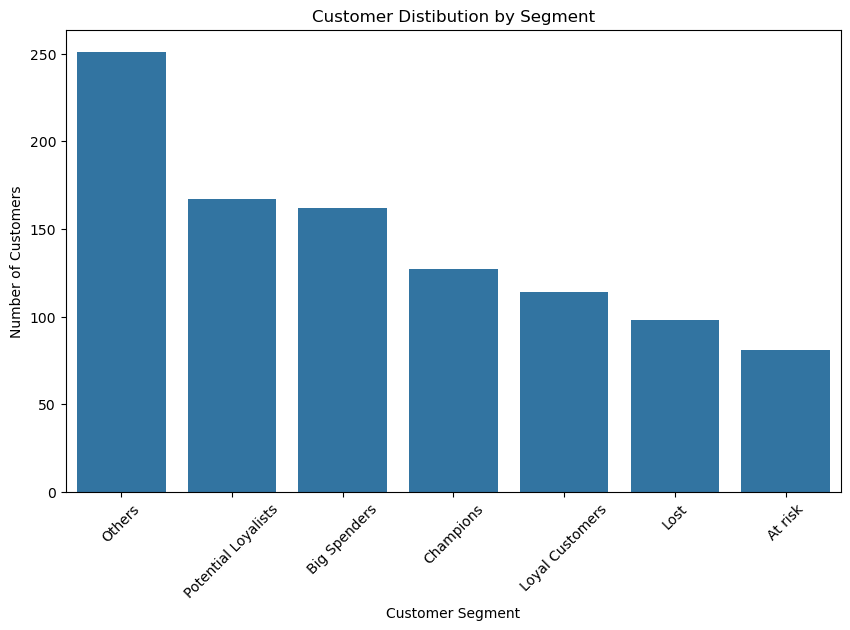

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_rfm , x="Segment", order =df_rfm["Segment"].value_counts().index)


plt.title("Customer Distibution by Segment")

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.show()

In [15]:
# Revenue Contribution by Segment

df_tran_segment = df_transactions.merge(
    df_rfm[["CustomerID","Segment"]],
    on ="CustomerID",
    how="left"
)
df_tran_segment.head()

,CustomerID,TransactionDate,TransactionAmount,Segment
0,CUST10771,2023-07-31,2383.07,Big Spenders
1,CUST10100,2024-03-10,497.54,Loyal Customers
2,CUST10031,2025-02-17,536.78,Big Spenders
3,CUST10987,2023-07-17,314.89,Big Spenders
4,CUST10831,2024-12-15,2543.19,Big Spenders


In [16]:
# Revenue contribution per segment

revenue_segment = df_tran_segment.groupby('Segment')['TransactionAmount'].sum().reset_index()

revenue_segment

,Segment,TransactionAmount
0,At risk,1741623.46
1,Big Spenders,4569923.99
2,Champions,3725144.54
3,Lost,1827944.96
4,Loyal Customers,3023023.74
5,Others,4490683.79
6,Potential Loyalists,3674855.18


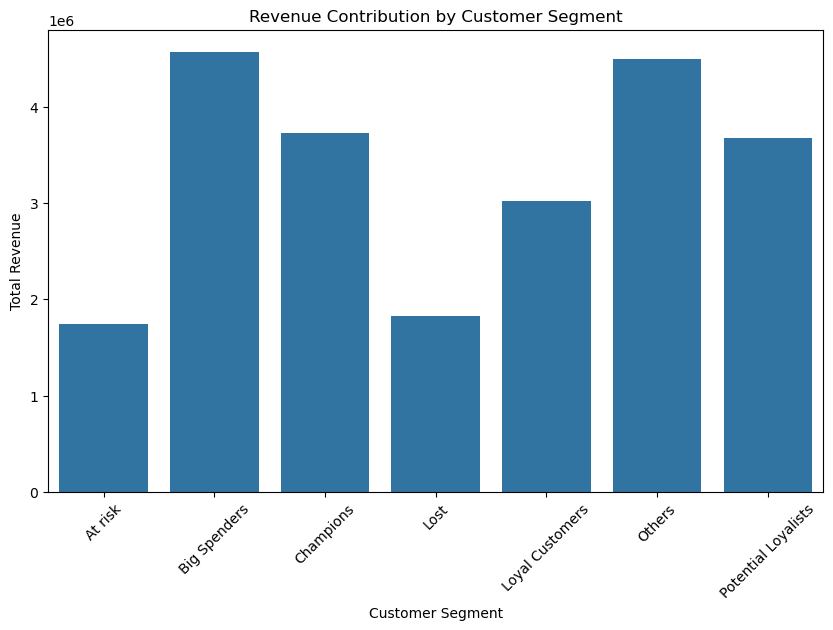

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(data=revenue_segment, x='Segment', y='TransactionAmount')

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.show()

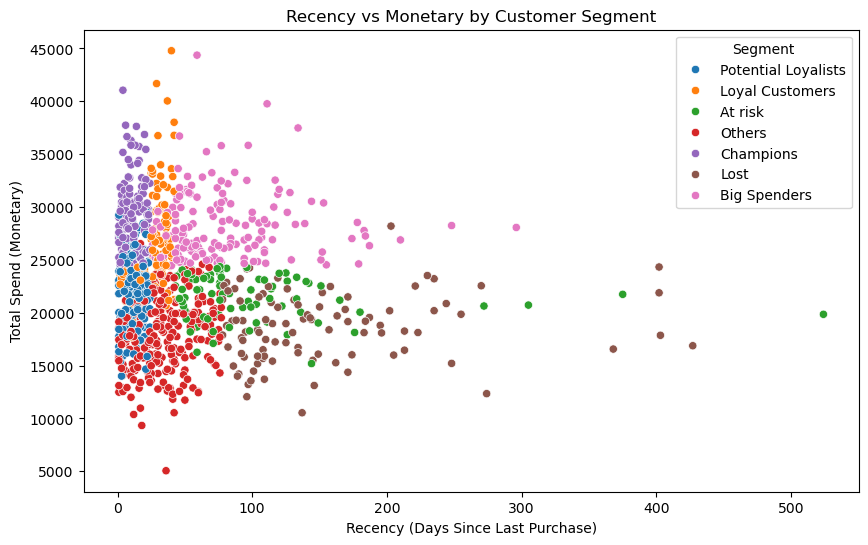

In [18]:
#  Recency vs Monetary scatter plot

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_rfm,
    x='Recency',
    y='Monetary',
    hue='Segment'
)

plt.title("Recency vs Monetary by Customer Segment")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Total Spend (Monetary)")

plt.show()

In [19]:
# Sort customers by spending

pareto_df = df_rfm.sort_values(by='Monetary', ascending=False)

pareto_df.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
944,CUST10944,40,31,44784.99,3,5,5,355,Loyal Customers
510,CUST10510,59,30,44367.33,2,5,5,255,Big Spenders
53,CUST10053,29,30,41674.56,3,5,5,355,Loyal Customers
776,CUST10776,4,33,41050.76,5,5,5,555,Champions
696,CUST10696,37,30,40035.48,3,5,5,355,Loyal Customers


In [20]:
# Calculate cumulative revenue percentage

pareto_df['CumulativeRevenue'] = pareto_df['Monetary'].cumsum()

total_revenue = pareto_df['Monetary'].sum()

pareto_df['CumulativePercent'] = 100 * pareto_df['CumulativeRevenue'] / total_revenue

pareto_df.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,CumulativeRevenue,CumulativePercent
944,CUST10944,40,31,44784.99,3,5,5,355,Loyal Customers,44784.99,0.194268
510,CUST10510,59,30,44367.33,2,5,5,255,Big Spenders,89152.32,0.386724
53,CUST10053,29,30,41674.56,3,5,5,355,Loyal Customers,130826.88,0.567500
776,CUST10776,4,33,41050.76,5,5,5,555,Champions,171877.64,0.745570
696,CUST10696,37,30,40035.48,3,5,5,355,Loyal Customers,211913.12,0.919235


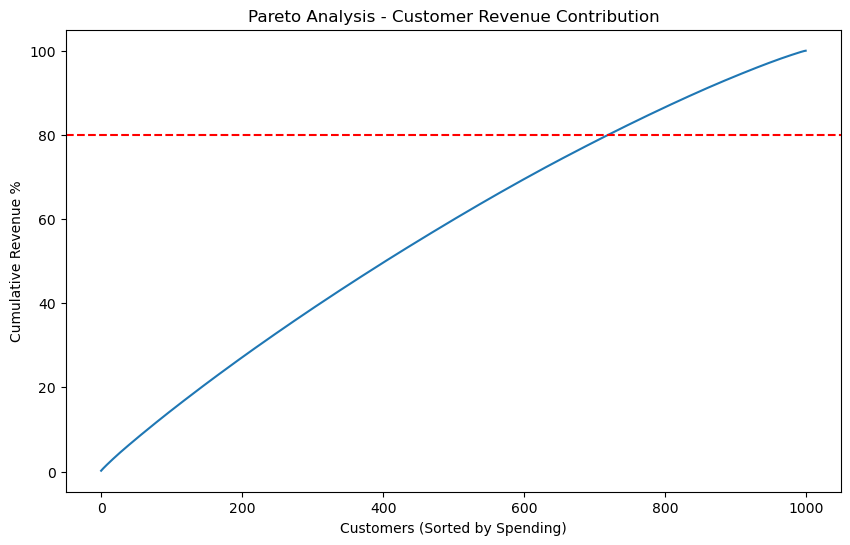

In [21]:
# Pareto chart
# The red line = 80% revenue

plt.figure(figsize=(10,6))

plt.plot(pareto_df['CumulativePercent'].values)

plt.axhline(80, color='red', linestyle='--')

plt.title("Pareto Analysis - Customer Revenue Contribution")
plt.xlabel("Customers (Sorted by Spending)")
plt.ylabel("Cumulative Revenue %")

plt.show()

## Customer distribution by city

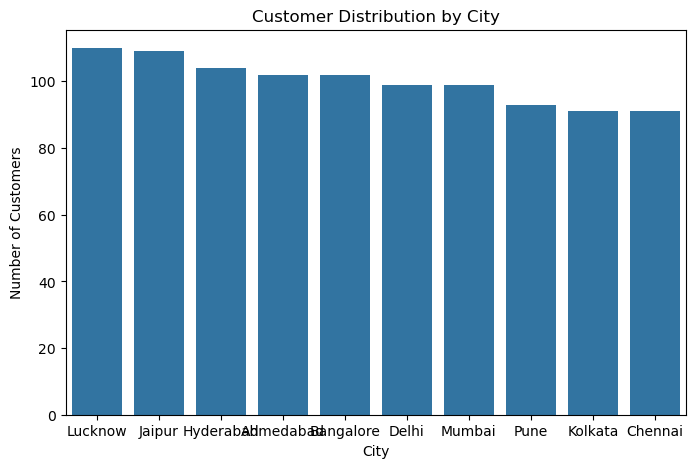

In [22]:
city_counts = df_customers['City'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=city_counts.index, y=city_counts.values)

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.show()

# Business Insights

### Key Business Insights

1. The dataset contains 1,000 customers and 23,050 transactions, indicating strong repeat purchase behavior.

2. Customer segmentation using RFM analysis identified several groups such as Champions, Loyal Customers, Big Spenders, Potential Loyalists, and At-Risk customers.

3. The largest segment is "Others" (251 customers), indicating many customers have moderate purchasing behavior and could be targeted with marketing campaigns.

4. Big Spenders generated the highest revenue (~₹4.57M), making them an important segment for premium offers and loyalty rewards.

5. Champions and Loyal Customers together contribute a significant portion of total revenue, showing strong engagement and brand loyalty.

6. The Potential Loyalists segment (167 customers) represents a strong opportunity for conversion into loyal customers through targeted promotions.

7. The At-Risk and Lost segments together represent ~179 customers, indicating potential churn that may require re-engagement campaigns.

8. Pareto analysis shows that approximately 75% of customers generate 80% of revenue, suggesting revenue is distributed across a relatively broad customer base rather than a small elite group.

9. Customers with low recency and high monetary value tend to fall into the Champions and Big Spenders segments, indicating highly valuable customers who purchase frequently.

10. Customers with high recency values (long time since last purchase) appear mostly in the At-Risk and Lost segments, indicating declining engagement.

# Marketing Recommendations

### Marketing Recommendations

1. Reward Champions with loyalty points, early access to sales, or premium memberships to retain high-value customers.

2. Nurture Potential Loyalists through personalized discounts and welcome offers to convert them into loyal customers.

3. Upsell Big Spenders with premium product recommendations and bundle offers.

4. Re-engage "At-Risk" Customers using limited-time discounts or reminder campaigns.

5. Analyze Lost Customers to understand why they stopped purchasing and improve retention strategies.

6. Focus targeted marketing campaigns on mid-tier segments, as they represent a large portion of the customer base and have potential to increase revenue.

### Conclusion

This analysis used RFM methodology to segment customers and identify high-value segments.

Key findings include:
- Champions and Big Spenders contribute significantly to revenue.
- Potential Loyalists represent strong future growth opportunities.
- At-risk customers require targeted re-engagement campaigns.

These insights can help the marketing team design personalized promotions, loyalty programs, and retention strategies.